In [1]:
import xarray as xr
import xrft
import matplotlib.pyplot as plt
import numpy as np
from xgcm import Grid
from datatree import open_datatree, DataTree 

In [2]:
ver_coord = xr.open_dataset('/home/db194/scratch_db194/mom6/may2025/exps_MOM6_channel/no_param_low_visc/MOM6_channel_12km_deep_no_sponge_seamount_ANN_test3_long/Vertical_coordinate.nc')

ERROR 1: PROJ: proj_create_from_database: Open of /ext3/miniforge/share/proj failed


In [3]:
ver_coord

<xarray.Dataset>
Dimensions:       (Layer: 30, Interface: 31)
Coordinates:
  * Layer         (Layer) float64 2.5 10.0 20.0 ... 3.47e+03 3.645e+03 3.848e+03
  * Interface     (Interface) float64 0.0 5.0 15.0 ... 3.595e+03 3.695e+03 4e+03
Data variables:
    ds            (Layer) float64 ...
    ds_interface  (Interface) float64 ...
Attributes:
    filename:  ./Vertical_coordinate.nc

In [9]:
#os_ANN_12 = xr.open_dataset('/home/db194/scratch_db194/mom6/may2025/exps_MOM6_channel/no_param_low_visc/MOM6_channel_12km_deep_no_sponge_seamount_ANN_test/ocean.stats.nc', decode_times=False)
os_ANN_12 = xr.open_dataset('/home/db194/scratch_db194/mom6/may2025/exps_MOM6_channel/no_param_low_visc/MOM6_channel_12km_deep_no_sponge_seamount_ANN_test3_long/ocean.stats.nc', decode_times=False)
os_no_param_12 = xr.open_dataset('/home/db194/scratch_db194/mom6/may2025/exps_MOM6_channel/no_param_low_visc/MOM6_channel_12km_deep_no_sponge_seamount/ocean.stats.nc', decode_times=False)
os_simple_GM = xr.open_dataset('/home/db194/scratch_db194/mom6/may2025/exps_MOM6_channel/no_param_low_visc/MOM6_channel_12km_deep_no_sponge_seamount_simple_GM/ocean.stats.nc', decode_times=False)
os_ANN_GM = xr.open_dataset('/home/db194/scratch_db194/mom6/may2025/exps_MOM6_channel/no_param_low_visc/MOM6_channel_12km_deep_no_sponge_seamount_ANN_GM/ocean.stats.nc', decode_times=False)

In [10]:
os_ANN_25 = xr.open_dataset('/home/db194/scratch_db194/mom6/may2025/exps_MOM6_channel/no_param_low_visc/MOM6_channel_25km_deep_no_sponge_seamount_ANN_test3_long/ocean.stats.nc', decode_times=False)
os_no_param_25 = xr.open_dataset('/home/db194/scratch_db194/mom6/may2025/exps_MOM6_channel/no_param_low_visc/MOM6_channel_25km_deep_no_sponge_seamount/ocean.stats.nc', decode_times=False)


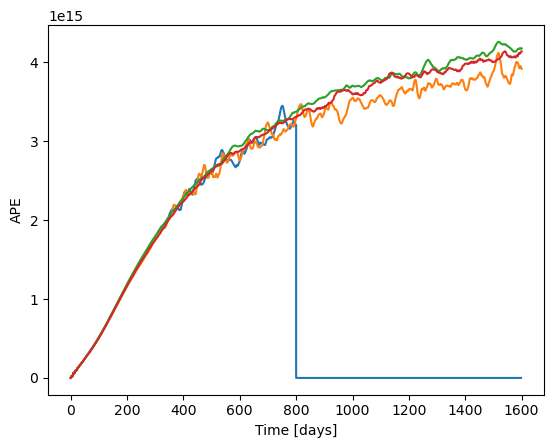

In [11]:
os_no_param_12.APE.sum('Interface').plot()
os_ANN_12.APE.sum('Interface').plot()
os_no_param_25.APE.sum('Interface').plot()
os_ANN_25.APE.sum('Interface').plot()

In [12]:
os_no_param.APE.sum('Interface').plot()
os_simple_GM.APE.sum('Interface').plot()
os_ANN_GM.APE.sum('Interface').plot()

os_ANN.APE.sum('Interface').plot()
os_ANN3.APE.sum('Interface').plot()

NameError: name 'os_no_param' is not defined

In [13]:
os_no_param.KE.sum('Layer').plot()
os_simple_GM.KE.sum('Layer').plot()
os_ANN_GM.KE.sum('Layer').plot()

os_ANN.KE.sum('Layer').plot()
os_ANN3.KE.sum('Layer').plot()

NameError: name 'os_no_param' is not defined

In [14]:
import glob

In [15]:
dir ='/home/db194/scratch_db194/mom6/may2025/exps_MOM6_channel/no_param_low_visc/MOM6_channel_12km_deep_no_sponge_seamount/'
files = sorted(glob.glob(dir+'prog__*.nc'))
files_z = sorted(glob.glob(dir+'prog_z_*.nc'))
               
ds_no_param = xr.open_mfdataset(files[:-1], decode_times=False)
ds_no_param_z = xr.open_mfdataset(files_z[:-1], decode_times=False)

In [16]:
def open_running(dir ='/home/db194/scratch_db194/mom6/may2025/exps_MOM6_channel/no_param_low_visc/MOM6_channel_12km_deep_no_sponge_seamount/'): 
    
    files = sorted(glob.glob(dir+'prog__*.nc'))
    files_z = sorted(glob.glob(dir+'prog_z_*.nc'))
               
    ds = xr.open_mfdataset(files[:-1], decode_times=False)
    ds_z = xr.open_mfdataset(files_z[:-1], decode_times=False)

    return ds, ds_z

In [17]:
ds_ANN_12, ds_ANN_z_12 = open_running('/home/db194/scratch_db194/mom6/may2025/exps_MOM6_channel/no_param_low_visc/MOM6_channel_12km_deep_no_sponge_seamount_ANN_test3_long/')

In [18]:
ds_12, ds_z_12 = open_running('/home/db194/scratch_db194/mom6/may2025/exps_MOM6_channel/no_param_low_visc/MOM6_channel_12km_deep_no_sponge_seamount/')

In [19]:
ds_25, ds_z_25 = open_running('/home/db194/scratch_db194/mom6/may2025/exps_MOM6_channel/no_param_low_visc/MOM6_channel_25km_deep_no_sponge_seamount/')

In [20]:
ds_ANN_25, ds_ANN_z_25 = open_running('/home/db194/scratch_db194/mom6/may2025/exps_MOM6_channel/no_param_low_visc/MOM6_channel_25km_deep_no_sponge_seamount_ANN_test3_long/')


In [21]:
oce_geo = xr.open_dataset('/home/db194/scratch_db194/mom6/may2025/exps_MOM6_channel/no_param_low_visc/MOM6_channel_12km_deep_no_sponge_seamount_ANN_test3_long/ocean_geometry.nc')

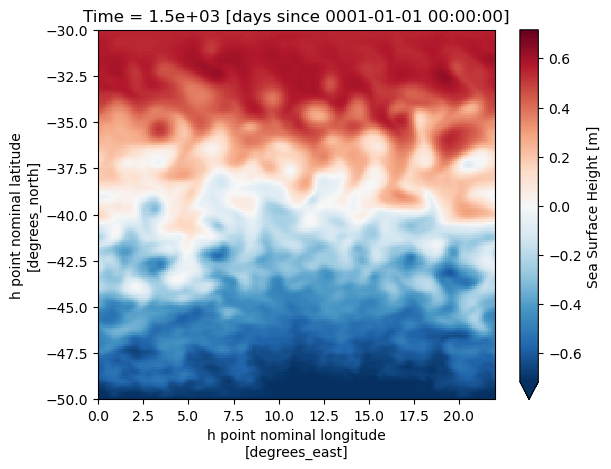

In [23]:
ds_ANN_12.ssh.isel(Time=-1).plot(robust=True)

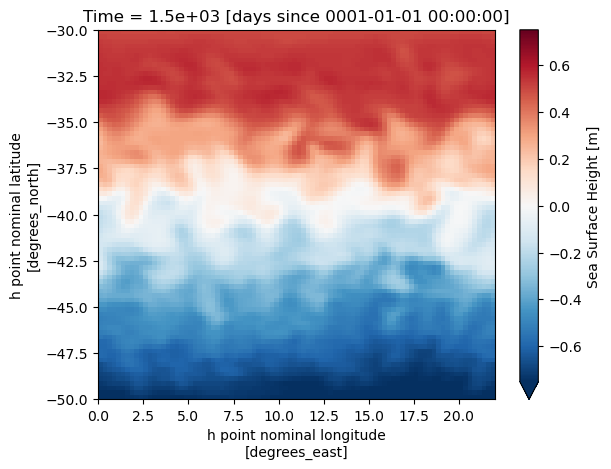

In [24]:
ds_ANN_25.ssh.isel(Time=-1).plot(robust=True)

In [23]:
ds_ANN_25

<xarray.Dataset>
Dimensions:          (xq: 89, yh: 80, zl: 30, Time: 150, xh: 88, yq: 81, zi: 31)
Coordinates:
  * xq               (xq) float64 0.0 0.25 0.5 0.75 ... 21.25 21.5 21.75 22.0
  * yh               (yh) float64 -49.88 -49.62 -49.38 ... -30.62 -30.38 -30.12
  * zl               (zl) float64 2.5 10.0 20.0 ... 3.47e+03 3.645e+03 3.848e+03
  * Time             (Time) float64 10.0 20.0 30.0 ... 1.48e+03 1.49e+03 1.5e+03
  * xh               (xh) float64 0.125 0.375 0.625 0.875 ... 21.38 21.62 21.88
  * yq               (yq) float64 -50.0 -49.75 -49.5 ... -30.5 -30.25 -30.0
  * zi               (zi) float64 0.0 5.0 15.0 ... 3.595e+03 3.695e+03 4e+03
Data variables: (12/26)
    u                (Time, zl, yh, xq) float32 dask.array<chunksize=(10, 30, 80, 89), meta=np.ndarray>
    v                (Time, zl, yq, xh) float32 dask.array<chunksize=(10, 30, 81, 88), meta=np.ndarray>
    h                (Time, zl, yh, xh) float64 dask.array<chunksize=(10, 30, 80, 88), meta=np.ndarray>
    Rd1              (Time, yh, xh) float64 dask.array<chunksize=(10, 80, 88), meta=np.ndarray>
    ssh              (Time, yh, xh) float64 dask.array<chunksize=(10, 80, 88), meta=np.ndarray>
    neutral_slope_x  (Time, zi, yh, xq) float64 dask.array<chunksize=(10, 31, 80, 89), meta=np.ndarray>
    ...               ...
    dhbardy          (Time, zl, yh, xh) float64 dask.array<chunksize=(10, 30, 80, 88), meta=np.ndarray>
    Fx               (Time, zl, yh, xh) float64 dask.array<chunksize=(10, 30, 80, 88), meta=np.ndarray>
    Fy               (Time, zl, yh, xh) float64 dask.array<chunksize=(10, 30, 80, 88), meta=np.ndarray>
    uhTrANN          (Time, zl, yh, xq) float64 dask.array<chunksize=(10, 30, 80, 89), meta=np.ndarray>
    vhTrANN          (Time, zl, yq, xh) float64 dask.array<chunksize=(10, 30, 81, 88), meta=np.ndarray>
    h_mask           (Time, zl, yh, xh) float64 dask.array<chunksize=(10, 30, 80, 88), meta=np.ndarray>
Attributes:
    filename:   prog__00010.nc
    title:      MOM Experiment
    grid_type:  regular
    grid_tile:  N/A

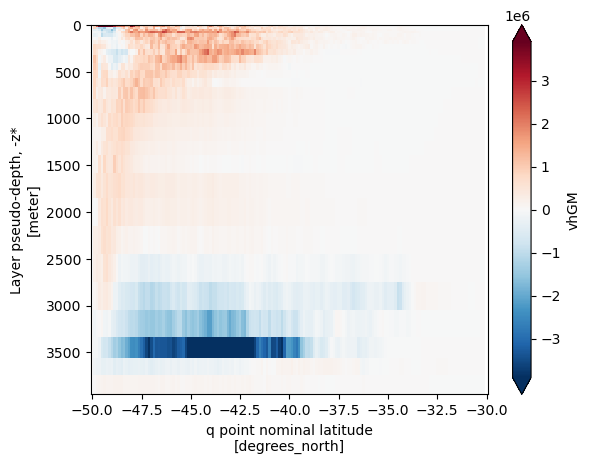

In [25]:
ds_ANN_12.vhGM.isel(Time=slice(-40,None)).mean(['Time','xh']).plot(robust=True)
plt.gca().invert_yaxis()

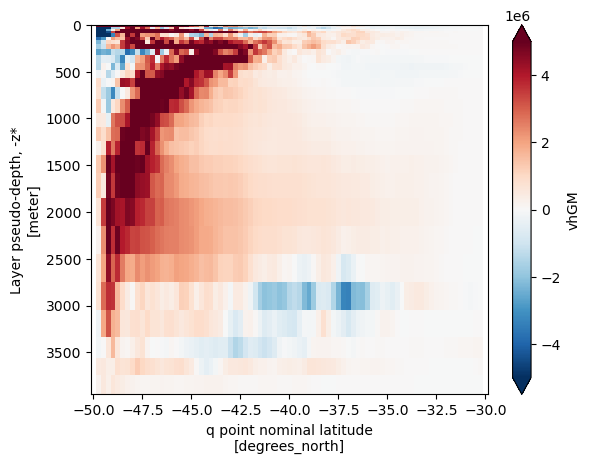

In [30]:
ds_ANN_25.vhGM.isel(Time=slice(-40,None)).mean(['Time','xh']).plot(vmin=-5e6)
plt.gca().invert_yaxis()

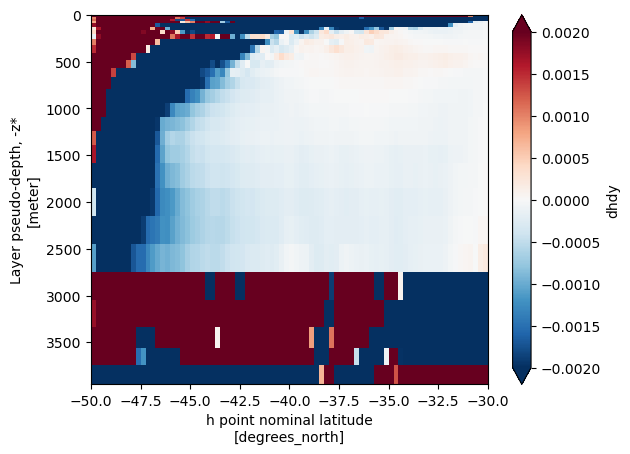

In [32]:
ds_ANN_25.dhdy.isel(Time=slice(-40,None)).mean(['Time','xh']).plot(vmin=-0.002)
plt.gca().invert_yaxis()

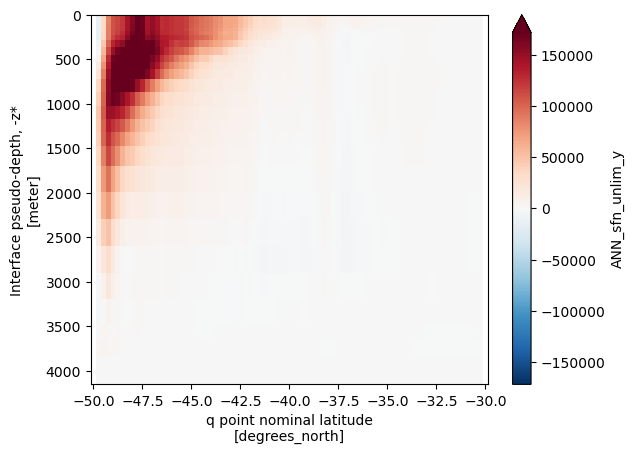

In [28]:
ds_ANN_25.ANN_sfn_unlim_y.isel(Time=slice(-40,None)).mean(['Time','xh']).plot(robust=True)
plt.gca().invert_yaxis()

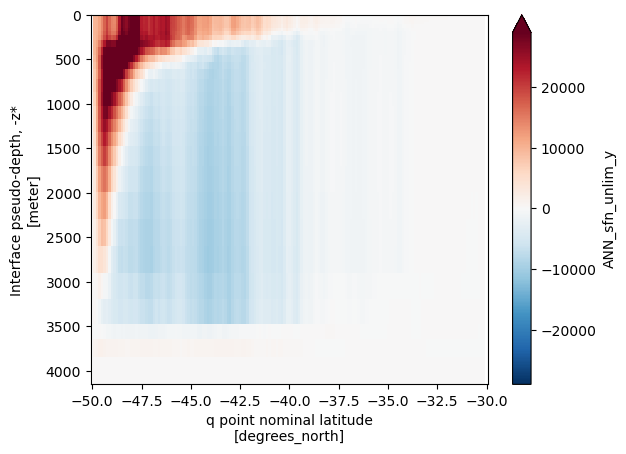

In [27]:
ds_ANN_12.ANN_sfn_unlim_y.isel(Time=slice(-40,None)).mean(['Time','xh']).plot(robust=True)
plt.gca().invert_yaxis()

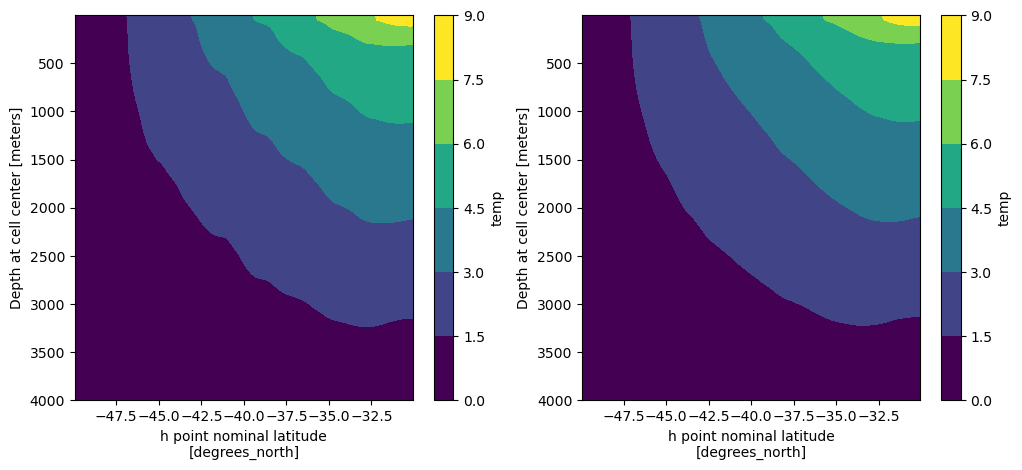

In [37]:
plt.figure(figsize=(12, 5))

plt.subplot(121)
ds_z_12.temp.isel(Time=slice(-40, None)).mean(['Time','xh']).plot.contourf()
plt.gca().invert_yaxis()

plt.subplot(122)
ds_ANN_z_12.temp.isel(Time=slice(-40, None)).mean(['Time','xh']).plot.contourf()
plt.gca().invert_yaxis()

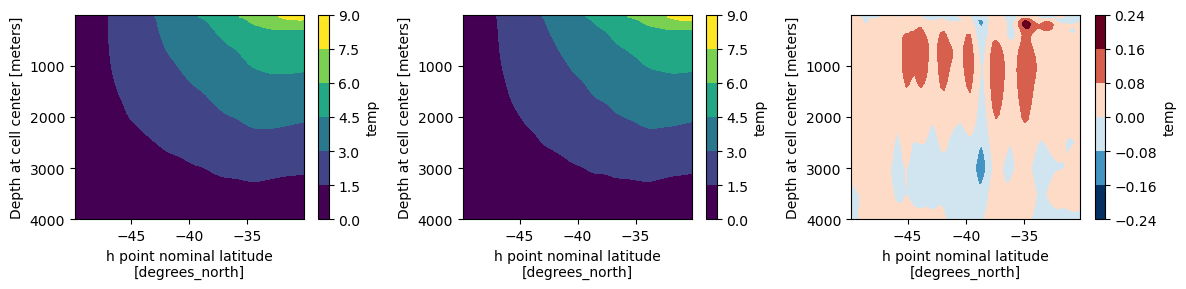

In [41]:
plt.figure(figsize=(12, 3))

plt.subplot(131)
ds_z_25.temp.isel(Time=slice(-40, None)).mean(['Time','xh']).plot.contourf()
plt.gca().invert_yaxis()

plt.subplot(132)
ds_ANN_z_25.temp.isel(Time=slice(-40, None)).mean(['Time','xh']).plot.contourf()
plt.gca().invert_yaxis()

plt.subplot(133)
(ds_z_25.temp - ds_ANN_z_25.temp).isel(Time=slice(-40, None)).mean(['Time','xh']).plot.contourf()
plt.gca().invert_yaxis()

plt.tight_layout()

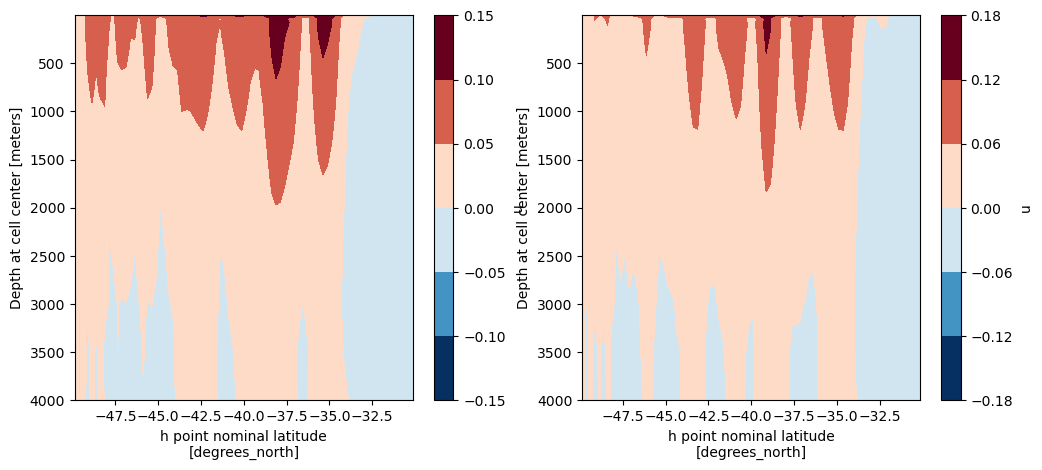

In [39]:
plt.figure(figsize=(12, 5))

plt.subplot(121)
ds_z_25.u.isel(Time=slice(-40, None)).mean(['Time','xq']).plot.contourf()
plt.gca().invert_yaxis()

plt.subplot(122)
ds_ANN_z_25.u.isel(Time=slice(-40, None)).mean(['Time','xq']).plot.contourf()
plt.gca().invert_yaxis()

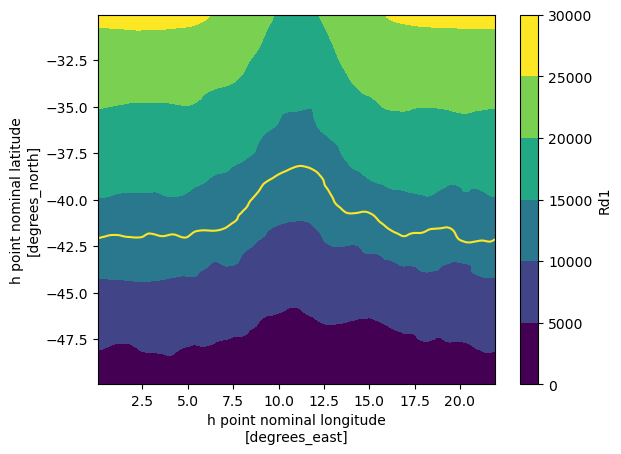

In [37]:
ds_ANN.Rd1.isel(Time=slice(-40,None)).mean('Time').plot.contourf()
ds_ANN.Rd1.isel(Time=slice(-40,None)).mean('Time').plot.contour(levels=[12500])

In [43]:
(ds_ANN.Rd1/(oce_geo.Ah**0.5)).plot()


KeyboardInterrupt



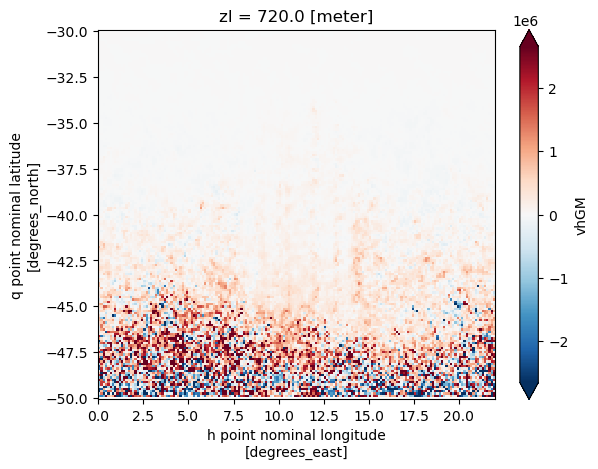

In [28]:
ds_ANN.vhGM.isel(Time=slice(-70,None)).isel(zl=15).mean(['Time']).plot(robust=True)


In [ ]:
ds_ANN.vhGM.isel(Time=slice(-40,None)).isel(xh=0).mean(['Time','xh']).plot(robust=True)
plt.gca().invert_yaxis()

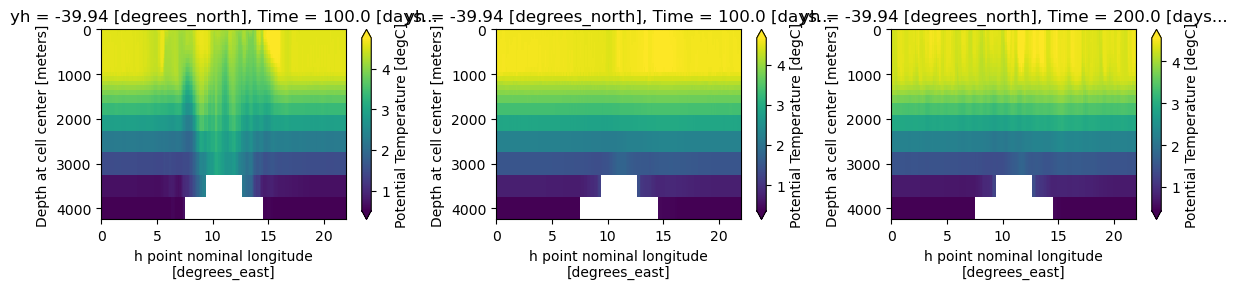

In [33]:
plt.figure(figsize=(12, 3))

plt.subplot(131)
ds_ANN_z.temp.isel(Time=-1, yh=80).plot(robust=True)
plt.gca().invert_yaxis()

plt.subplot(132)
ds_ANN_z_mask.temp.isel(Time=-1, yh=80).plot(robust=True)
plt.gca().invert_yaxis()

plt.subplot(133)
ds_no_param_z.temp.isel(Time=-1, yh=80).plot(robust=True)
plt.gca().invert_yaxis()

plt.tight_layout()

In [35]:
ds_ANN

<xarray.Dataset>
Dimensions:          (xq: 177, yh: 160, zl: 30, Time: 10, xh: 176, yq: 161,
                      zi: 31)
Coordinates:
  * xq               (xq) float64 0.0 0.125 0.25 0.375 ... 21.75 21.88 22.0
  * yh               (yh) float64 -49.94 -49.81 -49.69 ... -30.31 -30.19 -30.06
  * zl               (zl) float64 2.5 10.0 20.0 ... 3.47e+03 3.645e+03 3.848e+03
  * Time             (Time) float64 10.0 20.0 30.0 40.0 ... 70.0 80.0 90.0 100.0
  * xh               (xh) float64 0.0625 0.1875 0.3125 ... 21.69 21.81 21.94
  * yq               (yq) float64 -50.0 -49.88 -49.75 ... -30.25 -30.12 -30.0
  * zi               (zi) float64 0.0 5.0 15.0 ... 3.595e+03 3.695e+03 4e+03
Data variables: (12/26)
    u                (Time, zl, yh, xq) float32 ...
    v                (Time, zl, yq, xh) float32 ...
    h                (Time, zl, yh, xh) float64 ...
    Rd1              (Time, yh, xh) float64 ...
    ssh              (Time, yh, xh) float64 ...
    neutral_slope_x  (Time, zi, yh, xq) float64 ...
    ...               ...
    dhbardy          (Time, zl, yh, xh) float64 ...
    Fx               (Time, zl, yh, xh) float64 ...
    Fy               (Time, zl, yh, xh) float64 ...
    uhTrANN          (Time, zl, yh, xq) float64 ...
    vhTrANN          (Time, zl, yq, xh) float64 ...
    h_mask           (Time, zl, yh, xh) float64 ...
Attributes:
    filename:   prog__00010.nc
    title:      MOM Experiment
    grid_type:  regular
    grid_tile:  N/A

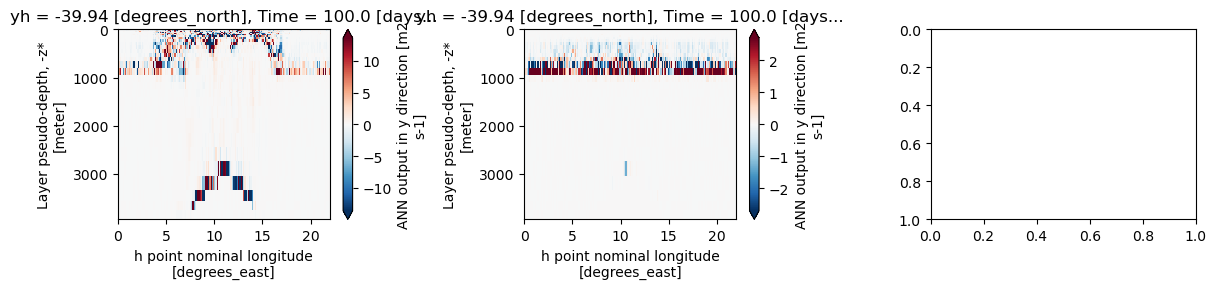

In [36]:
plt.figure(figsize=(12, 3))

plt.subplot(131)
ds_ANN.Fy.isel(Time=-1, yh=80).plot(robust=True)
plt.gca().invert_yaxis()

plt.subplot(132)
ds_ANN_mask.Fy.isel(Time=-1, yh=80).plot(robust=True)
plt.gca().invert_yaxis()

plt.subplot(133)
#ds_no_param_z.temp.isel(Time=-1, yh=80).plot(robust=True)
plt.gca().invert_yaxis()

plt.tight_layout()

In [40]:
ds_ANN

<xarray.Dataset>
Dimensions:          (xq: 177, yh: 160, zl: 30, Time: 10, xh: 176, yq: 161,
                      zi: 31)
Coordinates:
  * xq               (xq) float64 0.0 0.125 0.25 0.375 ... 21.75 21.88 22.0
  * yh               (yh) float64 -49.94 -49.81 -49.69 ... -30.31 -30.19 -30.06
  * zl               (zl) float64 2.5 10.0 20.0 ... 3.47e+03 3.645e+03 3.848e+03
  * Time             (Time) float64 10.0 20.0 30.0 40.0 ... 70.0 80.0 90.0 100.0
  * xh               (xh) float64 0.0625 0.1875 0.3125 ... 21.69 21.81 21.94
  * yq               (yq) float64 -50.0 -49.88 -49.75 ... -30.25 -30.12 -30.0
  * zi               (zi) float64 0.0 5.0 15.0 ... 3.595e+03 3.695e+03 4e+03
Data variables: (12/26)
    u                (Time, zl, yh, xq) float32 ...
    v                (Time, zl, yq, xh) float32 ...
    h                (Time, zl, yh, xh) float64 ...
    Rd1              (Time, yh, xh) float64 ...
    ssh              (Time, yh, xh) float64 ...
    neutral_slope_x  (Time, zi, yh, xq) float64 ...
    ...               ...
    dhbardy          (Time, zl, yh, xh) float64 ...
    Fx               (Time, zl, yh, xh) float64 ...
    Fy               (Time, zl, yh, xh) float64 ...
    uhTrANN          (Time, zl, yh, xq) float64 ...
    vhTrANN          (Time, zl, yq, xh) float64 ...
    h_mask           (Time, zl, yh, xh) float64 ...
Attributes:
    filename:   prog__00010.nc
    title:      MOM Experiment
    grid_type:  regular
    grid_tile:  N/A

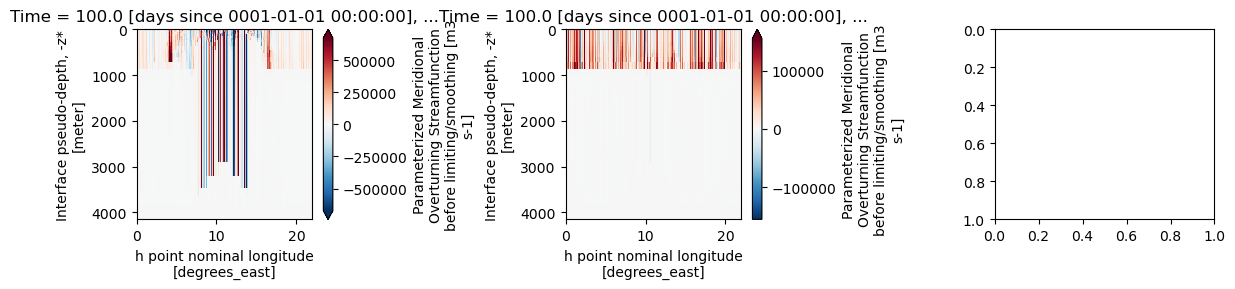

In [42]:
plt.figure(figsize=(12, 3))

plt.subplot(131)
ds_ANN.ANN_sfn_unlim_y.isel(Time=-1, yq=80).plot(robust=True)
plt.gca().invert_yaxis()

plt.subplot(132)
ds_ANN_mask.ANN_sfn_unlim_y.isel(Time=-1, yq=80).plot(robust=True)
plt.gca().invert_yaxis()

plt.subplot(133)
#ds_no_param_z.temp.isel(Time=-1, yh=80).plot(robust=True)
plt.gca().invert_yaxis()

plt.tight_layout()

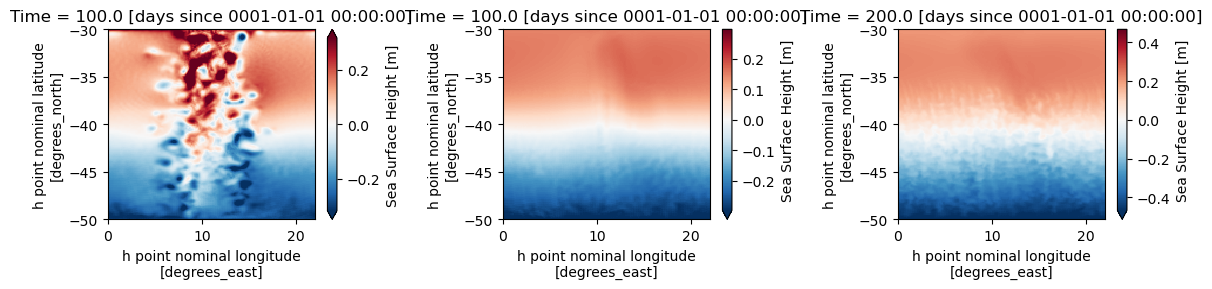

In [34]:
plt.figure(figsize=(12, 3))

plt.subplot(131)
ds_ANN.ssh.isel(Time=-1).plot(robust=True)
#plt.gca().invert_yaxis()

plt.subplot(132)
ds_ANN_mask.ssh.isel(Time=-1).plot(robust=True)
#plt.gca().invert_yaxis()

plt.subplot(133)
ds_no_param.ssh.isel(Time=-1).plot(robust=True)

plt.tight_layout()

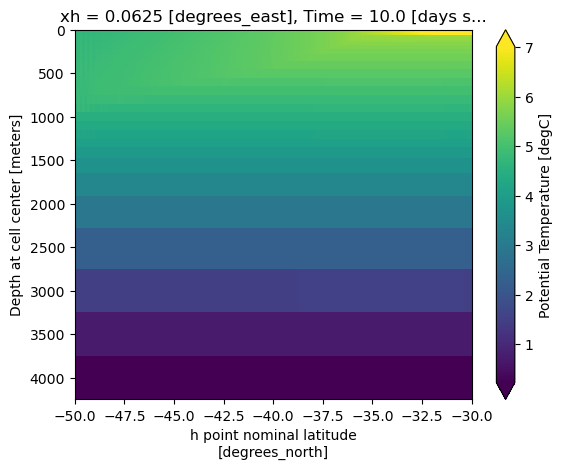

In [144]:
ds_ANN_z.temp.isel(Time=0, xh=0).plot(robust=True)
plt.gca().invert_yaxis()

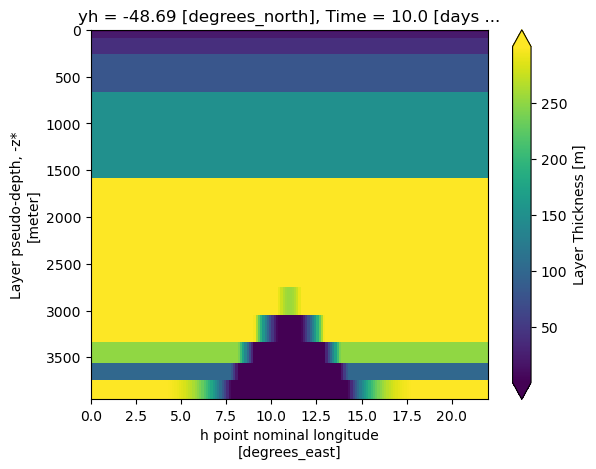

In [145]:
ds_ANN.h.isel(Time=0, yh=10).plot(robust=True)
plt.gca().invert_yaxis()

In [146]:
ds_ANN

<xarray.Dataset>
Dimensions:          (xq: 177, yh: 160, zl: 30, Time: 1, xh: 176, yq: 161,
                      zi: 31)
Coordinates:
  * xq               (xq) float64 0.0 0.125 0.25 0.375 ... 21.75 21.88 22.0
  * yh               (yh) float64 -49.94 -49.81 -49.69 ... -30.31 -30.19 -30.06
  * zl               (zl) float64 2.5 10.0 20.0 ... 3.47e+03 3.645e+03 3.848e+03
  * Time             (Time) float64 10.0
  * xh               (xh) float64 0.0625 0.1875 0.3125 ... 21.69 21.81 21.94
  * yq               (yq) float64 -50.0 -49.88 -49.75 ... -30.25 -30.12 -30.0
  * zi               (zi) float64 0.0 5.0 15.0 ... 3.595e+03 3.695e+03 4e+03
Data variables: (12/26)
    u                (Time, zl, yh, xq) float32 ...
    v                (Time, zl, yq, xh) float32 ...
    h                (Time, zl, yh, xh) float64 ...
    Rd1              (Time, yh, xh) float64 ...
    ssh              (Time, yh, xh) float64 ...
    neutral_slope_x  (Time, zi, yh, xq) float64 ...
    ...               ...
    dhbardy          (Time, zl, yh, xh) float64 ...
    Fx               (Time, zl, yh, xh) float64 ...
    Fy               (Time, zl, yh, xh) float64 ...
    uhTrANN          (Time, zl, yh, xq) float64 ...
    vhTrANN          (Time, zl, yq, xh) float64 ...
    h_mask           (Time, zl, yh, xh) float64 ...
Attributes:
    filename:   prog__00010.nc
    title:      MOM Experiment
    grid_type:  regular
    grid_tile:  N/A

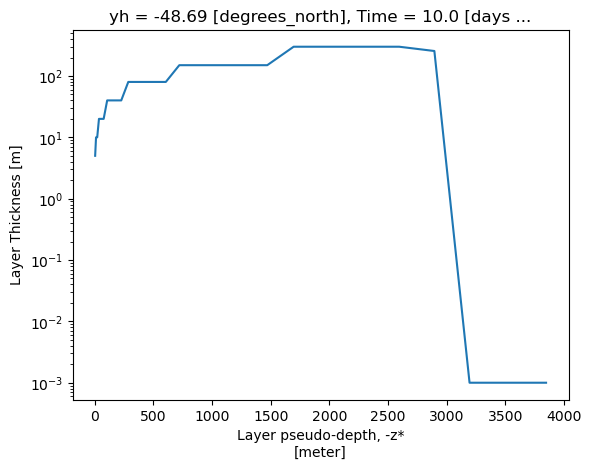

In [147]:
ds_ANN.h.isel(Time=0, yh=10, xh=88).plot()
plt.yscale('log')

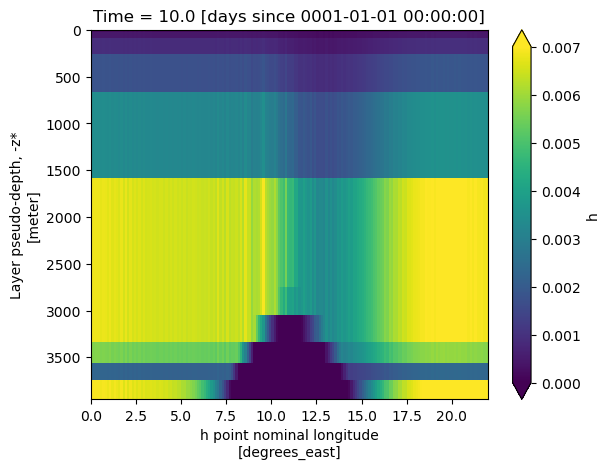

In [148]:
(ds_ANN.h.isel(Time=0, yh=80) - ds_ANN.h.isel(Time=0, yh=10)).plot(robust=True)
plt.gca().invert_yaxis()

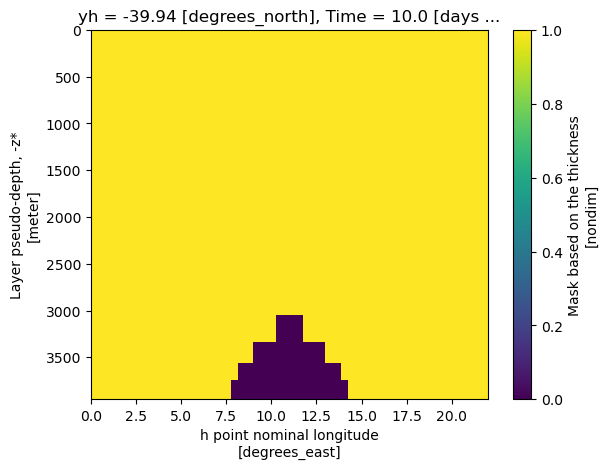

In [149]:
ds_ANN.h_mask.isel(Time=0, yh=80).plot(robust=True)
plt.gca().invert_yaxis()

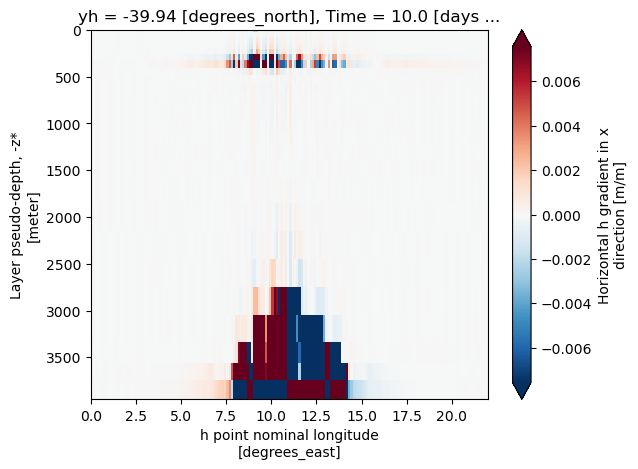

In [201]:
ds_ANN.dhdx.isel(Time=0, yh=80).plot(robust=True)
plt.gca().invert_yaxis()

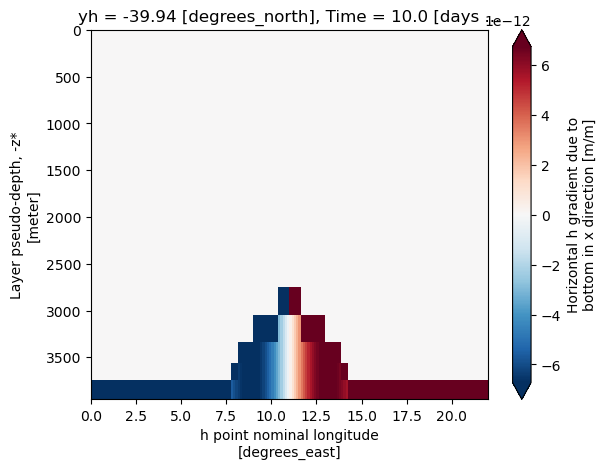

In [202]:
ds_ANN.dhbardx.isel(Time=0, yh=80).plot(robust=True)
plt.gca().invert_yaxis()

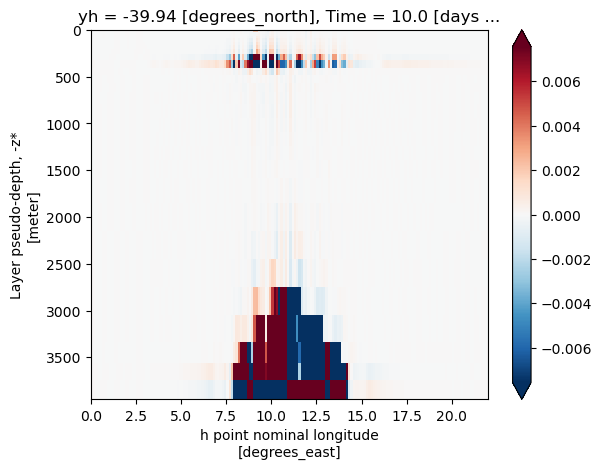

In [203]:
(ds_ANN.dhbardx + ds_ANN.dhdx).isel(Time=0, yh=80).plot(robust=True)
plt.gca().invert_yaxis()

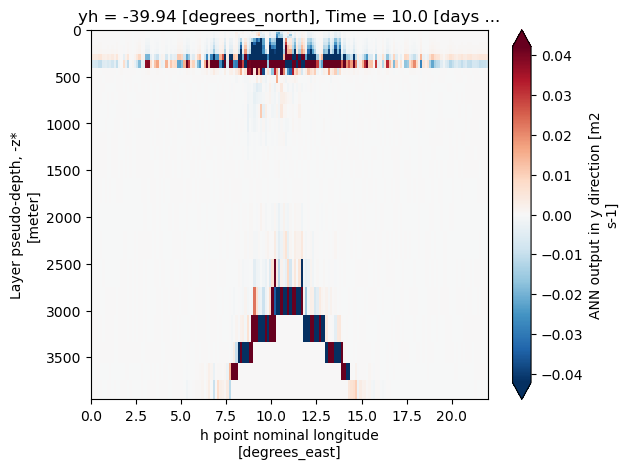

In [152]:
ds_ANN.Fy.isel(Time=0, yh=80).plot(robust=True)
plt.gca().invert_yaxis()

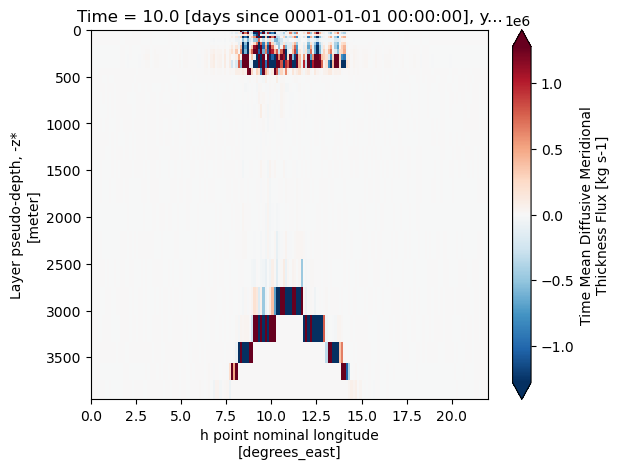

In [153]:
ds_ANN.vhGM.isel(Time=0, yq=80).plot(robust=True)
plt.gca().invert_yaxis()

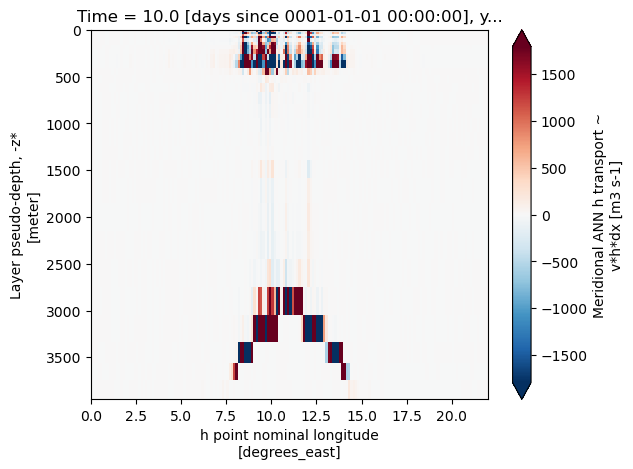

In [204]:
ds_ANN.vhTrANN.isel(Time=0, yq=80).plot(robust=True)
plt.gca().invert_yaxis()

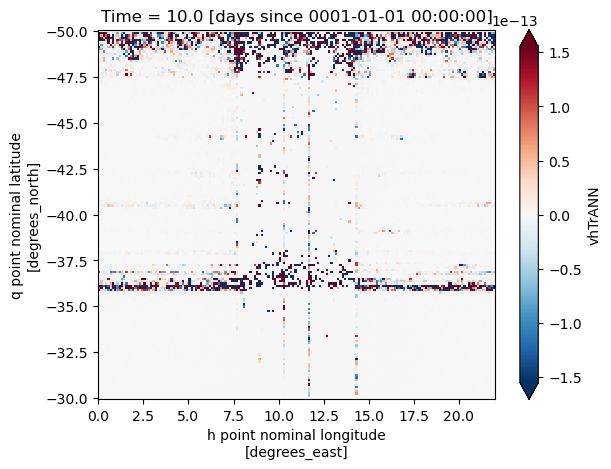

In [155]:
ds_ANN.vhTrANN.isel(zl=slice(0, None), Time=0).sum('zl').plot(robust=True)
plt.gca().invert_yaxis()

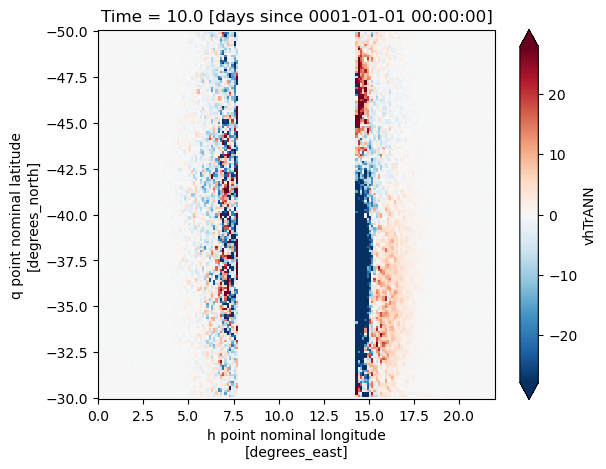

In [156]:
ds_ANN.vhTrANN.isel(zl=slice(0, -1), Time=0).sum('zl').plot(robust=True)
plt.gca().invert_yaxis()

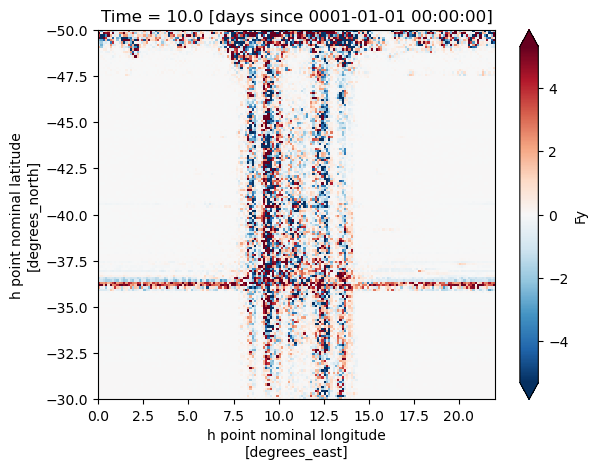

In [157]:
ds_ANN.Fy.isel(Time=0).sum('zl').plot(robust=True)
plt.gca().invert_yaxis()

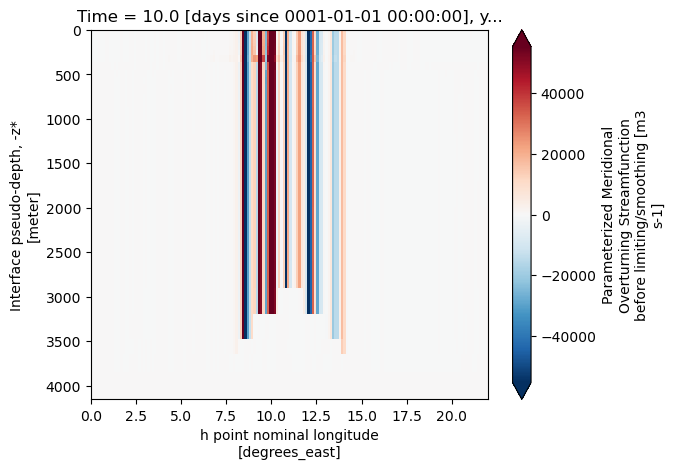

In [177]:
ds_ANN.ANN_sfn_unlim_y.isel(Time=0, yq=80).plot(robust=True)
plt.gca().invert_yaxis()

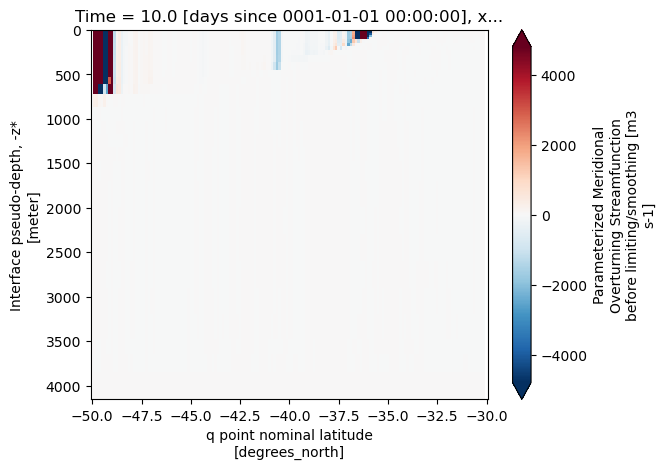

In [159]:
ds_ANN.ANN_sfn_unlim_y.isel(Time=0, xh=0).plot(robust=True)
plt.gca().invert_yaxis()

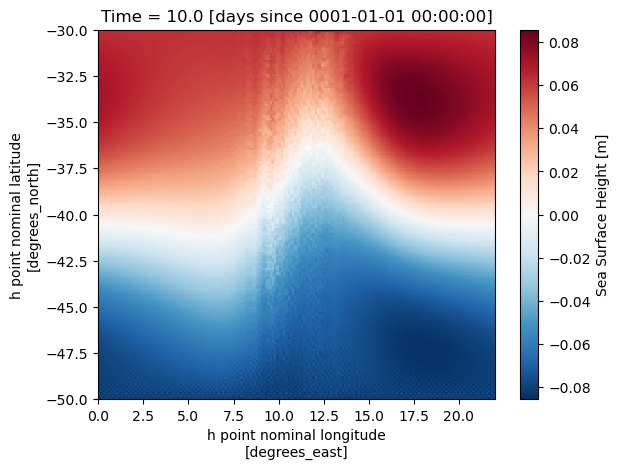

In [161]:
ds_ANN.ssh.isel(Time=-1).plot()

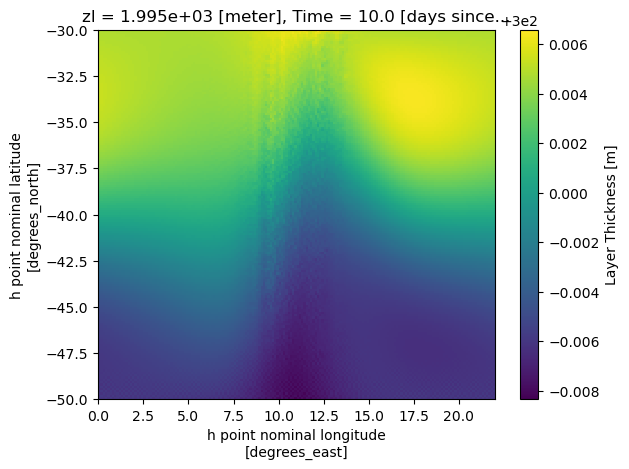

In [162]:
ds_ANN.h.isel(Time=-1, zl=-8).plot()

In [ ]:
ds_ANN.h.isel(Time=-1, zl=-8).plot()

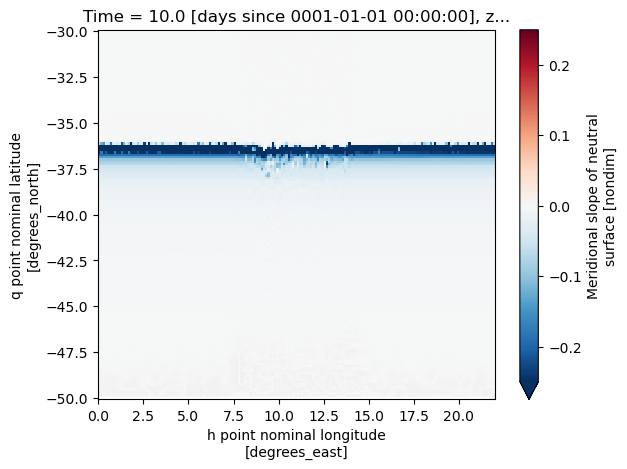

In [64]:
ds_ANN.neutral_slope_y.isel(Time=0, zi=5).plot(robust=True)

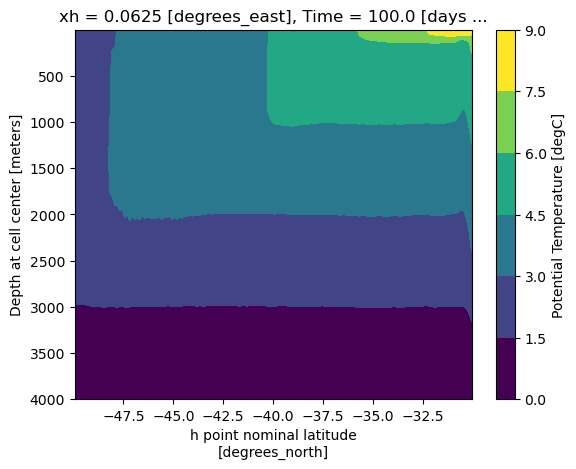

In [70]:
ds_ANN_z.temp.isel(Time=-1, xh=0).plot.contourf()
plt.gca().invert_yaxis()

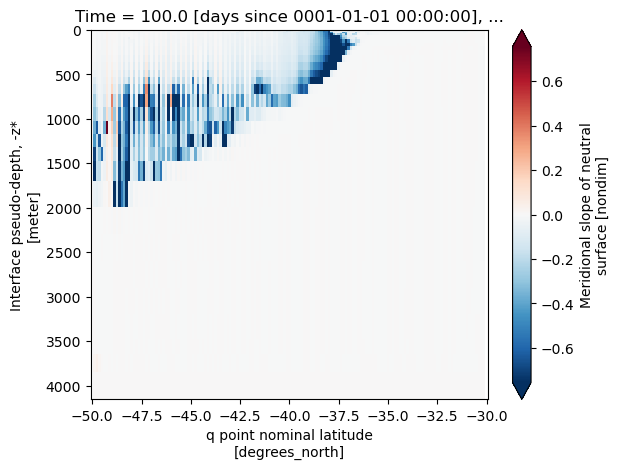

In [71]:
ds_ANN.neutral_slope_y.isel(Time=-1, xh=5).plot(robust=True)
plt.gca().invert_yaxis()

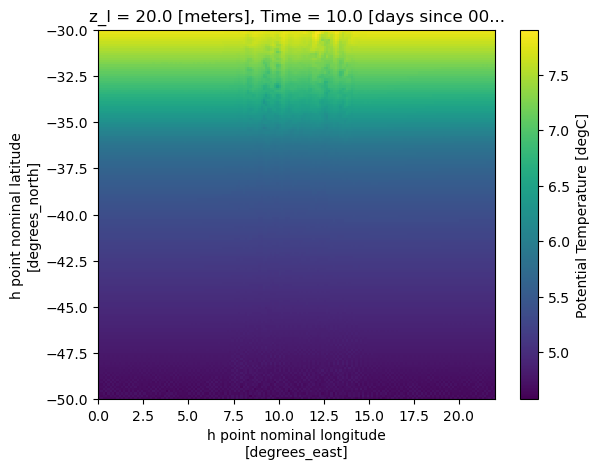

In [53]:
ds_ANN_z.temp.isel(Time=0, z_l=2).plot()

In [18]:
dir = '/home/db194/scratch_db194/mom6/may2025/exps_MOM6_channel/no_param_low_visc/MOM6_channel_12km_deep_no_sponge_seamount/'
import glob
files = sorted(glob.glob(dir + "prog__*.nc")) 

In [19]:
files_z = sorted(glob.glob(dir + "prog_z_*.nc")) 

In [20]:
ds = xr.open_mfdataset(files[:-1], decode_times=False)

In [35]:
ds_geom = xr.open_dataset(dir + 'ocean_geometry.nc')

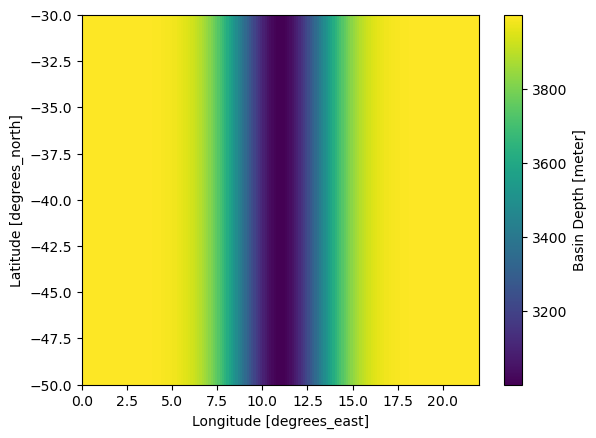

In [37]:
ds_geom.D.plot()

In [21]:
ds_z = xr.open_mfdataset(files_z[:-1], decode_times=False)

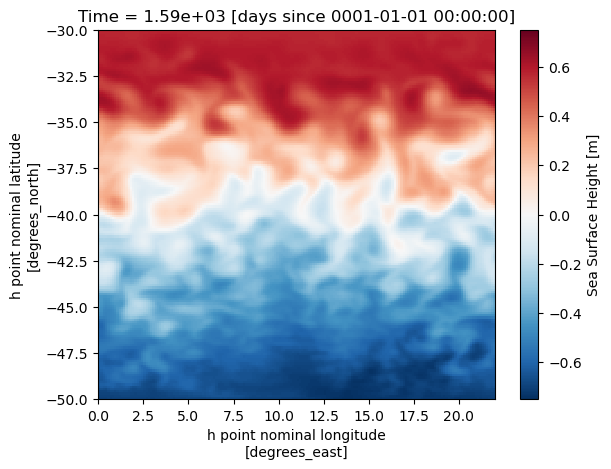

In [25]:
ds.ssh.isel(Time=-1).plot()

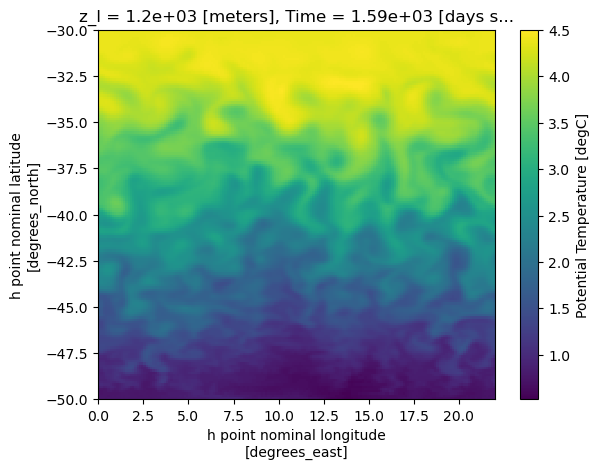

In [31]:
ds_z.temp.isel(Time=-1, z_l=20).plot()
#plt.gca().invert_yaxis()

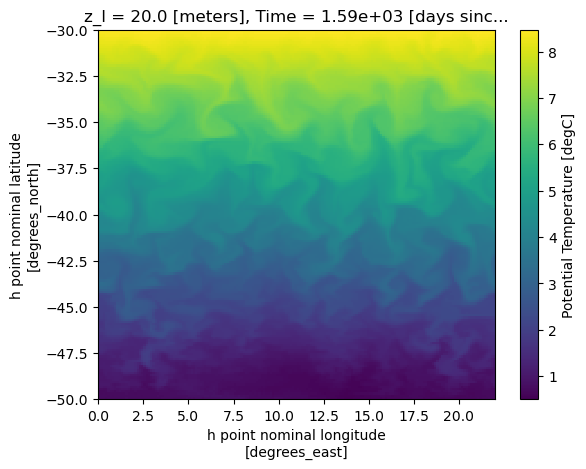

In [30]:
ds_z.temp.isel(Time=-1, z_l=2).plot()


In [2]:
exp_dir = '/home/db194/scratch_db194/mom6/may2025/exps_MOM6_channel/'

In [3]:
res = [5, 12, 25, 50, 100] 

In [12]:
model_dic = {}
for r in res: 
    print(r)
    model_dic[str(r)] = xr.open_dataset(exp_dir+'no_param/'+
                                        'MOM6_channel_'+str(r)+'km/ocean.stats.nc', 
                                        decode_times=False)

5
12
25
50
100


In [13]:
model_dic_GM = {}
for r in res: 
    print(r)
    model_dic_GM[str(r)] = xr.open_dataset(exp_dir+'simple_GM/'+
                                        'MOM6_channel_'+str(r)+'km/ocean.stats.nc', 
                                        decode_times=False)

5
12
25
50
100


In [14]:
model_dic_ANN = {}
for r in res: 
    print(r)
    model_dic_ANN[str(r)] = xr.open_dataset(exp_dir+'ANN_GM/'+
                                        'MOM6_channel_'+str(r)+'km/ocean.stats.nc', 
                                        decode_times=False)

5
12
25
50
100


In [7]:
model_dic['5']

<xarray.Dataset>
Dimensions:        (Layer: 30, Interface: 31, Time: 2250)
Coordinates:
  * Layer          (Layer) float64 2.5 10.0 22.5 ... 2.3e+03 2.5e+03 2.8e+03
  * Interface      (Interface) float64 0.0 5.0 15.0 ... 2.4e+03 2.6e+03 3e+03
  * Time           (Time) float64 0.0 1.0 2.0 ... 2.247e+03 2.248e+03 2.249e+03
Data variables: (12/17)
    Ntrunc         (Time) float64 ...
    En             (Time) float64 ...
    APE            (Time, Interface) float64 ...
    KE             (Time, Layer) float64 ...
    H0             (Time, Interface) float64 ...
    Mass_lay       (Time, Layer) float64 ...
    ...             ...
    Salt           (Time) float64 ...
    Salt_chg       (Time) float64 ...
    Salt_anom      (Time) float64 ...
    Heat           (Time) float64 ...
    Heat_chg       (Time) float64 ...
    Heat_anom      (Time) float64 ...
Attributes:
    filename:  ./ocean.stats.nc

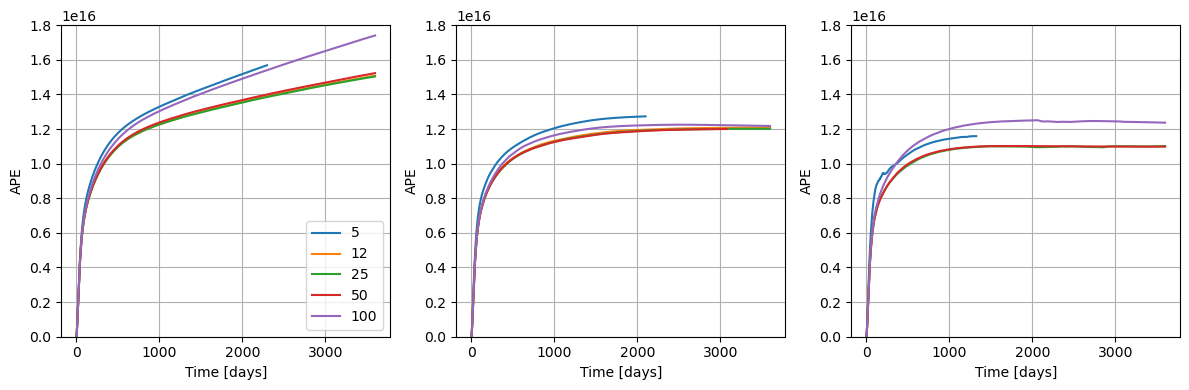

In [17]:
plt.figure(figsize=(12, 4))

plt.subplot(131)
for r in res: 
    model_dic[str(r)].APE.sum('Interface').plot(label=str(r))
plt.legend()
plt.ylim(0, 1.8e16)
plt.grid()

plt.subplot(132)
for r in res: 
    model_dic_GM[str(r)].APE.sum('Interface').plot(label=str(r))
plt.ylim(0, 1.8e16)
plt.grid()

plt.subplot(133)
for r in res: 
    model_dic_ANN[str(r)].APE.sum('Interface').plot(label=str(r))

plt.ylim(0, 1.8e16)
plt.grid()
plt.tight_layout()

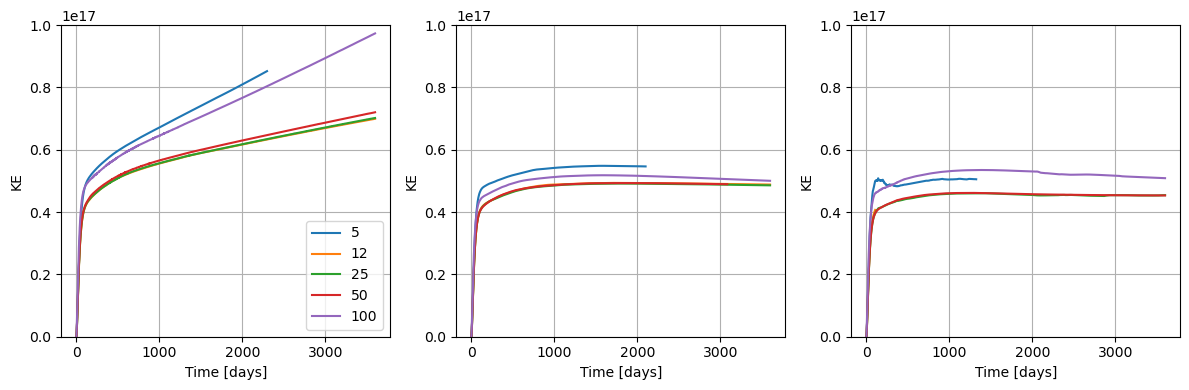

In [20]:
plt.figure(figsize=(12, 4))

plt.subplot(131)
for r in res: 
    model_dic[str(r)].KE.sum('Layer').plot(label=str(r))
plt.legend()
plt.ylim(0, 10e16)
plt.grid()

plt.subplot(132)
for r in res: 
    model_dic_GM[str(r)].KE.sum('Layer').plot(label=str(r))
plt.ylim(0, 10e16)
plt.grid()

plt.subplot(133)
for r in res: 
    model_dic_ANN[str(r)].KE.sum('Layer').plot(label=str(r))
plt.ylim(0, 10e16)
plt.grid()
plt.tight_layout()

In [136]:
os = xr.open_mfdataset('/home/db194/scratch_db194/mom6/may2025/exps_MOM6_channel/no_param_low_visc/MOM6_channel_25km/ocean.stats.nc', decode_times=False)
#os12 = xr.open_mfdataset('/home/db194/scratch_db194/mom6/may2025/exps_MOM6_channel/no_param_low_visc/MOM6_channel_12km/ocean.stats.nc', decode_times=False)
#os12_deep = xr.open_mfdataset('/home/db194/scratch_db194/mom6/may2025/exps_MOM6_channel/no_param_low_visc/MOM6_channel_12km_deep/ocean.stats.nc', decode_times=False)
os12_deep_no_sponge = xr.open_mfdataset('/home/db194/scratch_db194/mom6/may2025/exps_MOM6_channel/no_param_low_visc/MOM6_channel_12km_deep_no_sponge/ocean.stats.nc', decode_times=False)
os12_deep_no_sponge_seamount = xr.open_mfdataset('/home/db194/scratch_db194/mom6/may2025/exps_MOM6_channel/no_param_low_visc/MOM6_channel_12km_deep_no_sponge_seamount/ocean.stats.nc', decode_times=False)

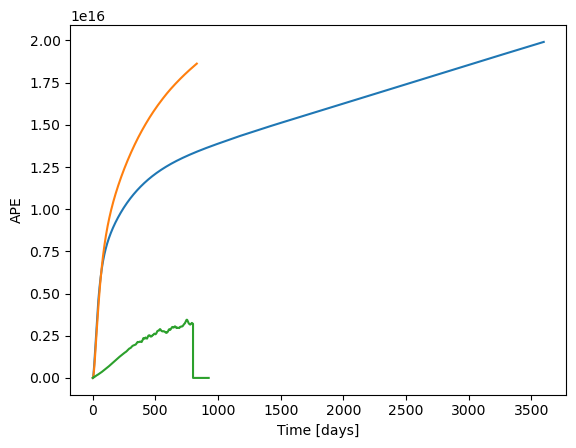

In [137]:
os.APE.sum('Interface').plot()
#os12.APE.sum('Interface').plot()
#os12_deep.APE.sum('Interface').plot()
os12_deep_no_sponge.APE.sum('Interface').plot()
os12_deep_no_sponge_seamount.APE.sum('Interface').plot()

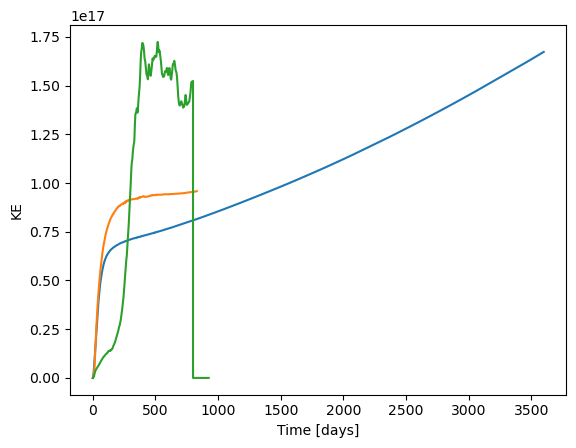

In [138]:
os.KE.sum('Layer').plot()
#os12.KE.sum('Layer').plot()
#os12_deep.KE.sum('Layer').plot()
os12_deep_no_sponge.KE.sum('Layer').plot()
os12_deep_no_sponge_seamount.KE.sum('Layer').plot()

In [107]:
ds = xr.open_mfdataset('/home/db194/scratch_db194/mom6/may2025/exps_MOM6_channel/no_param_low_visc/MOM6_channel_12km_deep_no_sponge/prog__00521.nc')
ds_z = xr.open_mfdataset('/home/db194/scratch_db194/mom6/may2025/exps_MOM6_channel/no_param_low_visc/MOM6_channel_12km_deep_no_sponge/prog_z__00521.nc')

In [126]:
ds = xr.open_mfdataset('/home/db194/scratch_db194/mom6/may2025/exps_MOM6_channel/no_param_low_visc/MOM6_channel_12km_deep_no_sponge_seamount/prog__*.nc')
ds_z = xr.open_mfdataset('/home/db194/scratch_db194/mom6/may2025/exps_MOM6_channel/no_param_low_visc/MOM6_channel_12km_deep_no_sponge_seamount/prog_z__*.nc')

In [127]:
ds_z

<xarray.Dataset>
Dimensions:  (xh: 176, yh: 160, z_l: 30, z_i: 31, Time: 800, xq: 177, yq: 161)
Coordinates:
  * xh       (xh) float64 0.0625 0.1875 0.3125 0.4375 ... 21.69 21.81 21.94
  * yh       (yh) float64 -49.94 -49.81 -49.69 -49.56 ... -30.31 -30.19 -30.06
  * z_l      (z_l) float64 2.5 10.0 20.0 32.5 ... 2.5e+03 3e+03 3.5e+03 4e+03
  * z_i      (z_i) float64 0.0 5.0 15.0 25.0 ... 3.25e+03 3.75e+03 4.25e+03
  * Time     (Time) object 0001-01-02 00:00:00 ... 0003-03-12 00:00:00
  * xq       (xq) float64 0.0 0.125 0.25 0.375 0.5 ... 21.62 21.75 21.88 22.0
  * yq       (yq) float64 -50.0 -49.88 -49.75 -49.62 ... -30.25 -30.12 -30.0
Data variables:
    temp     (Time, z_l, yh, xh) float32 dask.array<chunksize=(10, 30, 160, 176), meta=np.ndarray>
    umo      (Time, z_l, yh, xq) float32 dask.array<chunksize=(10, 30, 160, 177), meta=np.ndarray>
    vmo      (Time, z_l, yq, xh) float32 dask.array<chunksize=(10, 30, 161, 176), meta=np.ndarray>
    u        (Time, z_l, yh, xq) float32 dask.array<chunksize=(10, 30, 160, 177), meta=np.ndarray>
    v        (Time, z_l, yq, xh) float32 dask.array<chunksize=(10, 30, 161, 176), meta=np.ndarray>
    h        (Time, z_l, yh, xh) float64 dask.array<chunksize=(10, 30, 160, 176), meta=np.ndarray>
Attributes:
    filename:   prog_z__00001.nc
    title:      MOM Experiment
    grid_type:  regular
    grid_tile:  N/A

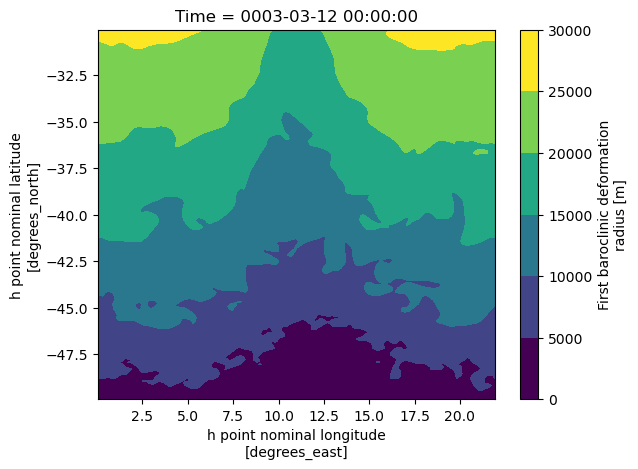

In [128]:
ds.Rd1.isel(Time=-1).plot.contourf()

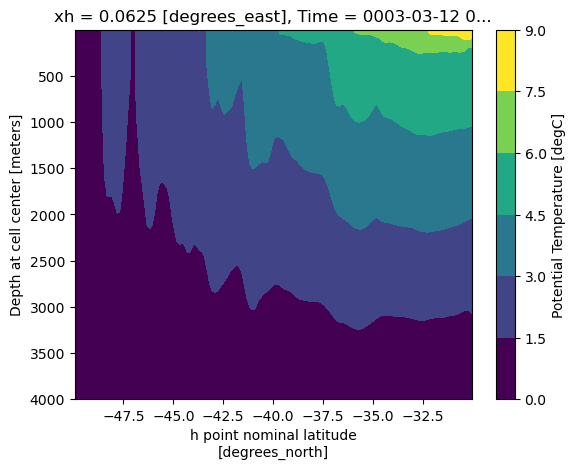

In [129]:
ds_z.temp.isel(Time=-1, xh=0).plot.contourf()
plt.gca().invert_yaxis()

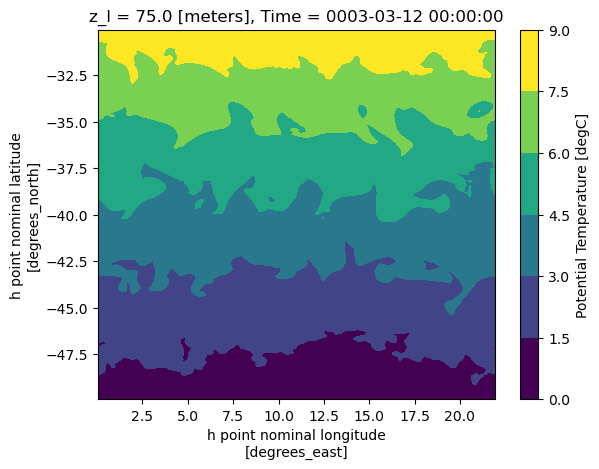

In [130]:
ds_z.temp.isel(Time=-1, z_l=5).plot.contourf()


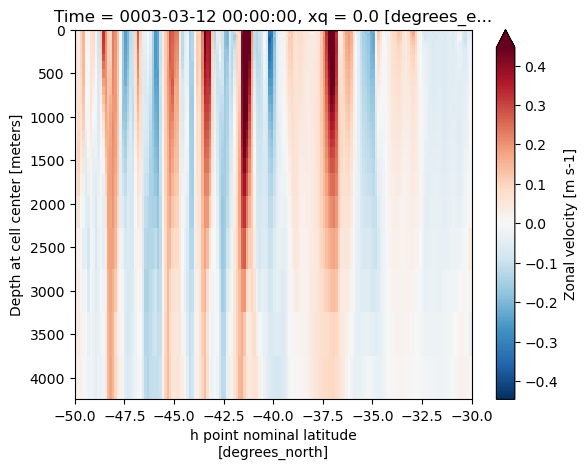

In [131]:
ds_z.u.isel(Time=-1, xq=0).plot(robust=True)
plt.gca().invert_yaxis()

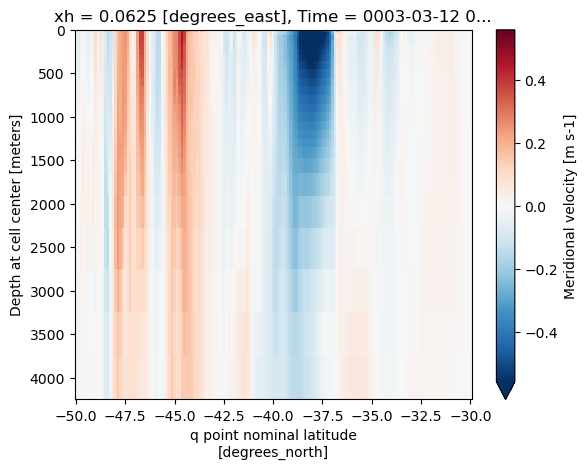

In [132]:
ds_z.v.isel(Time=-1, xh=0).plot(robust=True)
plt.gca().invert_yaxis()

In [35]:
ds = xr.open_mfdataset('/home/db194/scratch_db194/mom6/may2025/exps_MOM6_channel/no_param_low_visc/MOM6_channel_25km/prog__00001.nc')
ds12_deep = xr.open_mfdataset('/home/db194/scratch_db194/mom6/may2025/exps_MOM6_channel/no_param_low_visc/MOM6_channel_12km_deep/prog__00001.nc')
ds12 = xr.open_mfdataset('/home/db194/scratch_db194/mom6/may2025/exps_MOM6_channel/no_param_low_visc/MOM6_channel_12km/prog__00001.nc')

In [22]:
ds_z = xr.open_mfdataset('/home/db194/scratch_db194/mom6/may2025/exps_MOM6_channel/no_param_low_visc/MOM6_channel_25km/prog_z__00001.nc')
ds12_deep_z = xr.open_mfdataset('/home/db194/scratch_db194/mom6/may2025/exps_MOM6_channel/no_param_low_visc/MOM6_channel_12km_deep/prog_z__00001.nc')
ds12_z = xr.open_mfdataset('/home/db194/scratch_db194/mom6/may2025/exps_MOM6_channel/no_param_low_visc/MOM6_channel_12km/prog_z__00001.nc')
#ds12_z = xr.open_mfdataset('/home/db194/scratch_db194/mom6/may2025/exps_MOM6_channel/no_param_low_visc/MOM6_channel_12km/prog_z__00001.nc')
#ds12_z = xr.open_mfdataset('/home/db194/scratch_db194/mom6/may2025/exps_MOM6_channel/no_param_low_visc/MOM6_channel_12km/prog_z__00721.nc')

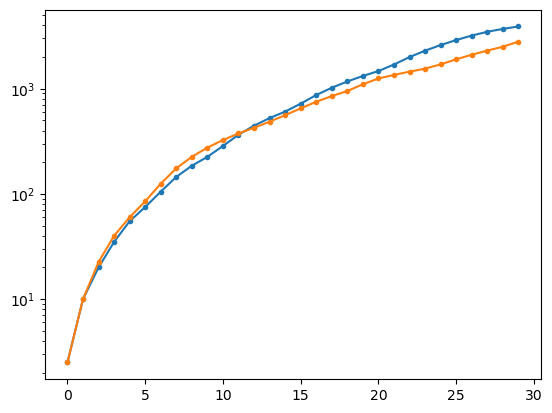

In [36]:
plt.plot(ds12_deep.zl.values, marker='.')
plt.plot(ds12.zl.values, marker='.')
plt.yscale('log')

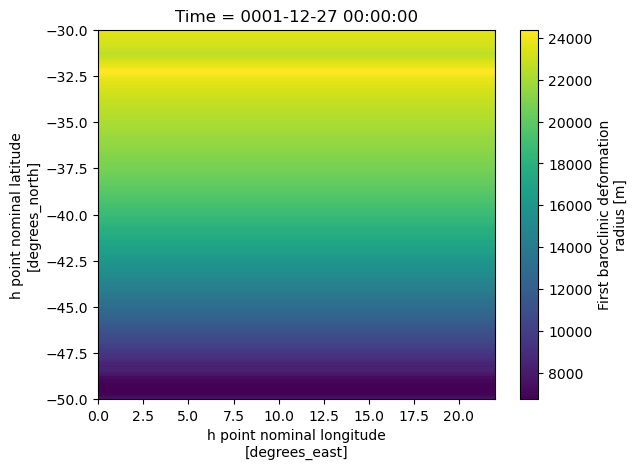

In [37]:
ds12_deep.Rd1.isel(Time=-1).plot()

In [85]:
ALE_RESOLUTION = [5.0, 
                  10.0, 10.0, 
                  20.0, 20.0, 20.0,
                  40.0, 40.0, 40.0, 40.0,
                  80.0, 80.0, 80.0, 80.0, 80.0, 
                  150.0, 150.0, 150.0, 150.0, 150.0,150.0, 
                  300.0, 300.0, 300.0, 300.0, 300.0, 300.0, 250.0, 200.
                 ]


                  

In [88]:
np.cumsum(ALE_RESOLUTION)

array([   5.,   15.,   25.,   45.,   65.,   85.,  125.,  165.,  205.,
        245.,  325.,  405.,  485.,  565.,  645.,  795.,  945., 1095.,
       1245., 1395., 1545., 1845., 2145., 2445., 2745., 3045., 3345.,
       3595., 3795.])

In [72]:
ALE_res_old = [5.0, 10.0, 15.0, 20.0, 20.0, 30.0, 50.0, 50.0, 50.0,50.0,50.0, 50.0,50.0,70.0,80.0, 100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,200.00,200.00,200.0, 200.0, 200.0, 200.0  ]

In [73]:
len(ALE_res_old)

30

In [55]:
ds12_z.z_l

<xarray.DataArray 'z_l' (z_l: 30)>
array([  50.,  150.,  250.,  350.,  450.,  550.,  650.,  750.,  850.,  950.,
       1050., 1150., 1250., 1350., 1450., 1550., 1650., 1750., 1850., 1950.,
       2050., 2150., 2250., 2350., 2450., 2550., 2650., 2750., 2850., 2950.])
Coordinates:
  * z_l      (z_l) float64 50.0 150.0 250.0 350.0 ... 2.75e+03 2.85e+03 2.95e+03
Attributes:
    long_name:       Depth at cell center
    units:           meters
    cartesian_axis:  Z
    positive:        down
    edges:           z_i

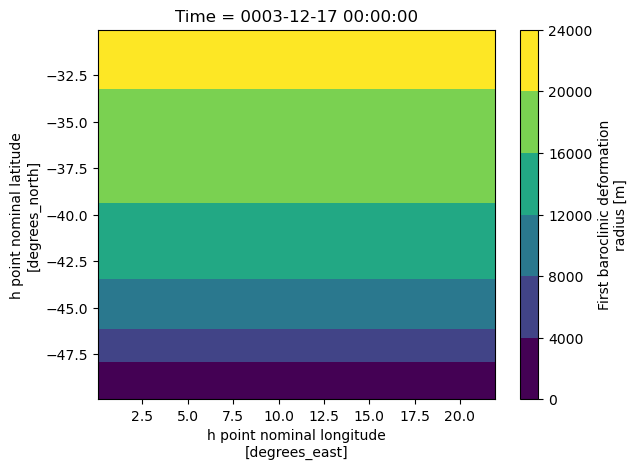

In [54]:
ds12.Rd1.isel(Time=-1).plot.contourf()

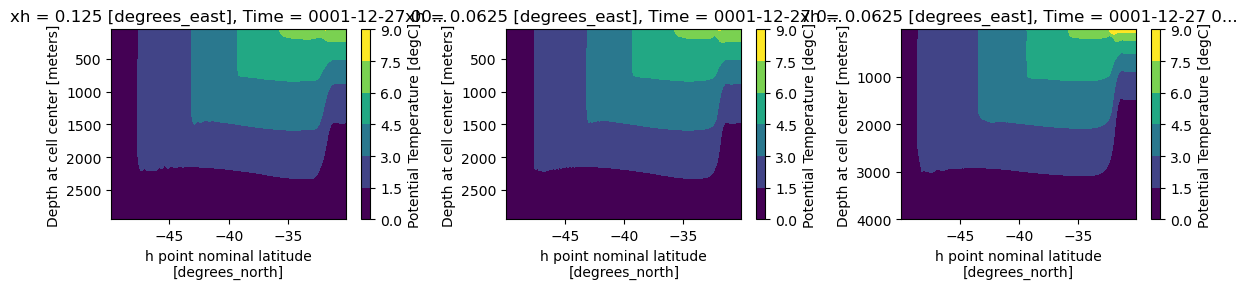

In [26]:
plt.figure(figsize=(12, 3))

plt.subplot(131)
ds_z.temp.isel(Time=-1, xh=0).plot.contourf()
plt.gca().invert_yaxis()

plt.subplot(132)
ds12_z.temp.isel(Time=-1, xh=0).plot.contourf()
plt.gca().invert_yaxis()

plt.subplot(133)
ds12_deep_z.temp.isel(Time=-1, xh=0).plot.contourf()
plt.gca().invert_yaxis()

plt.tight_layout()

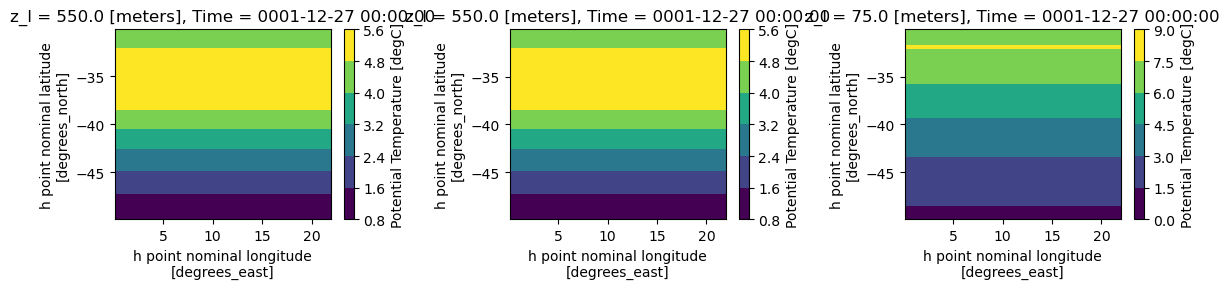

In [28]:
plt.figure(figsize=(12, 3))

plt.subplot(131)
ds_z.temp.isel(Time=-1, z_l=5).plot.contourf()


plt.subplot(132)
ds12_z.temp.isel(Time=-1, z_l=5).plot.contourf()


plt.subplot(133)
ds12_deep_z.temp.isel(Time=-1, z_l=5).plot.contourf()


plt.tight_layout()

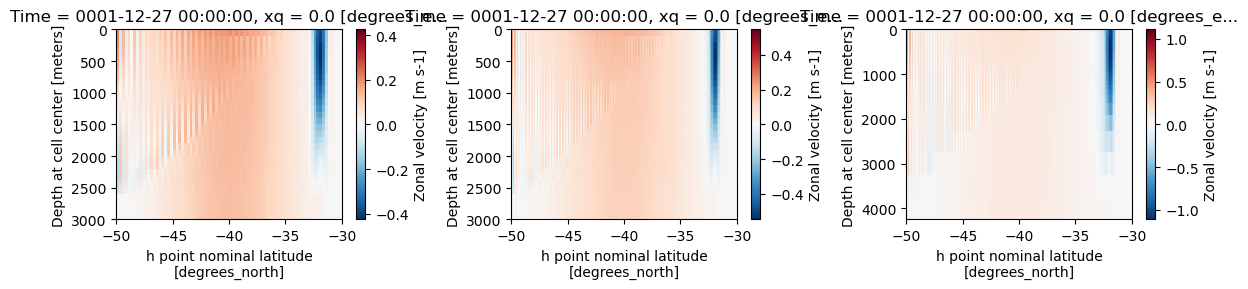

In [31]:
plt.figure(figsize=(12, 3))

plt.subplot(131)
ds_z.u.isel(Time=-1, xq=0).plot()
plt.gca().invert_yaxis()

plt.subplot(132)
ds12_z.u.isel(Time=-1, xq=0).plot()
plt.gca().invert_yaxis()

plt.subplot(133)
ds12_deep_z.u.isel(Time=-1, xq=0).plot()
plt.gca().invert_yaxis()

plt.tight_layout()

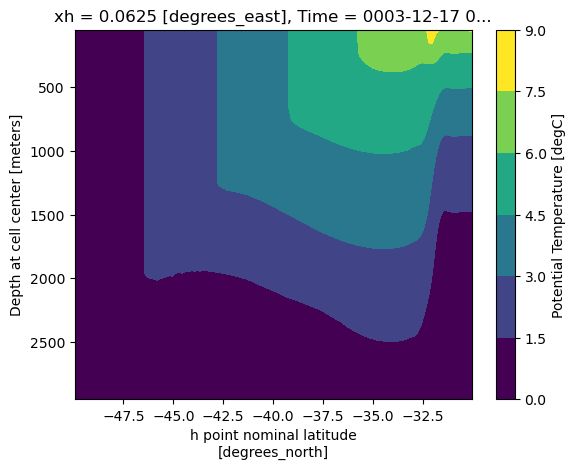

In [26]:
ds12_z.temp.isel(Time=-1, xh=0).plot.contourf()
plt.gca().invert_yaxis()

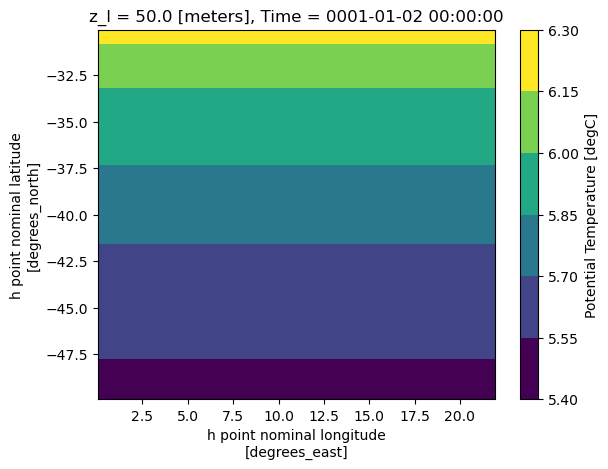

In [40]:
ds12_z.temp.isel(Time=0, z_l=0).plot.contourf()


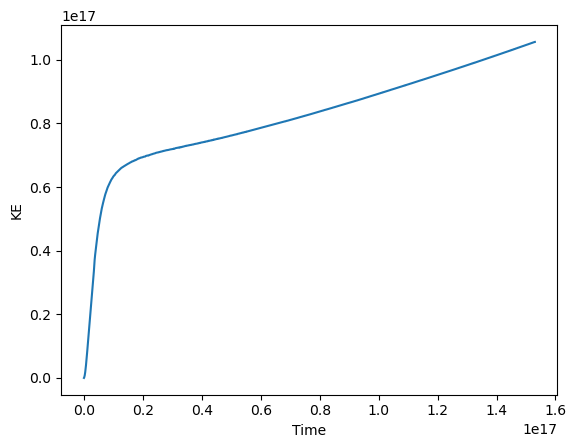

In [42]:
os.KE.sum('Layer').plot()

In [36]:
ds = xr.open_mfdataset('/home/db194/scratch_db194/mom6/may2025/exps_MOM6_channel/no_param/MOM6_channel_25km/prog__*.nc')

In [35]:
ds_z = xr.open_mfdataset('/home/db194/scratch_db194/mom6/may2025/exps_MOM6_channel/no_param/MOM6_channel_25km/prog_z_*.nc')

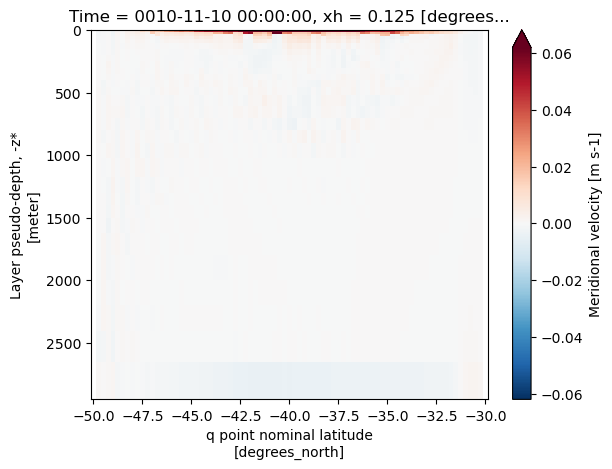

In [37]:
ds.v.isel(Time=-1, xh=0).plot(robust=True)
plt.gca().invert_yaxis()

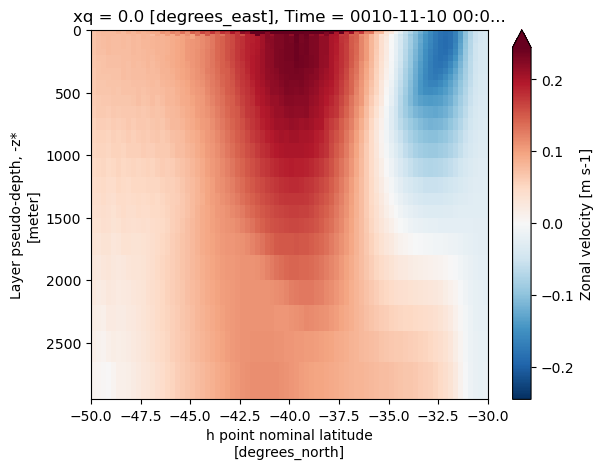

In [38]:
ds.u.isel(Time=-1, xq=0).plot(robust=True)
plt.gca().invert_yaxis()

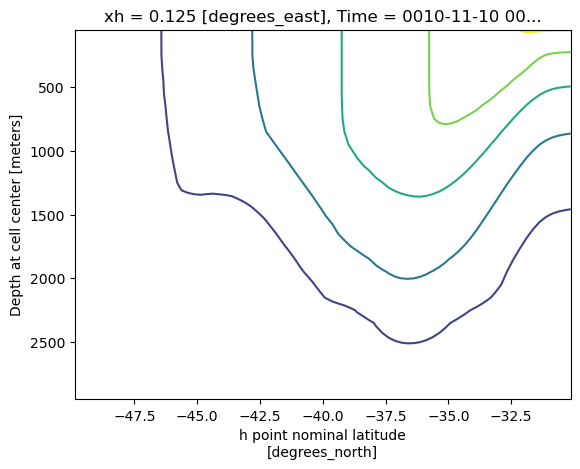

In [39]:
ds_z.temp.isel(Time=-1, xh=0).plot.contour(robust=True)
plt.gca().invert_yaxis()